# Exploring The Titanic Dataset

This notebook analyzes the titanic dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset

df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Dataset Shape

print(df.shape)
print(df.columns)

(891, 12)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


In [3]:
# Data Types

df.dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
# Missing Values
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
age_df = df.dropna(subset=['Age']).copy()

In [6]:
# Data Preparation

df = df.drop(['Cabin', 'Embarked', 'Ticket'], axis=1).copy()

In [7]:
df = df.rename(columns={'SibSp': 'Siblings_Spouses_Aboard'})

In [8]:
# Check for duplicated rows

df.duplicated().sum()

np.int64(0)

In [9]:
print(df["Survived"].value_counts())
print(df["Sex"].value_counts())
print(df["Pclass"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


**Note:** About 19.8% of passengers had missing age values. These passengers were excluded only from the age-related analysis because their age group could not be determined reliably.

In [10]:
# Defining age groups

age_df['Age_Group'] = pd.cut(age_df['Age'], bins=[0, 13, 20, 30, 60, 100],
       labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Older Adult'],
       right=False)

In [11]:
# Data Analysis: Gender Survival Rate

df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [12]:
# Pclass survival rate

df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [13]:
# Age group survival rate

age_df.groupby('Age_Group')['Survived'].mean()

Age_Group
Child          0.579710
Teen           0.410526
Young Adult    0.350000
Adult          0.417763
Older Adult    0.269231
Name: Survived, dtype: float64

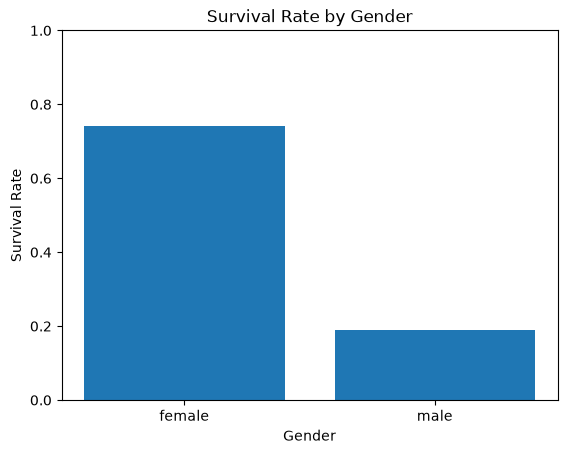

In [14]:
# Data Visualization

gender_survival = df.groupby('Sex')['Survived'].mean()

plt.bar(gender_survival.index, gender_survival.values)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

**Observation:** Female passengers had a much higher survival rate than male passengers, suggesting that gender was strongly associated with survival.

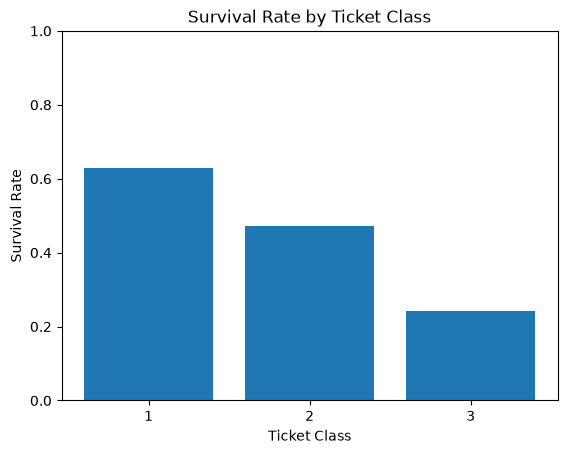

In [15]:
pclass_survival = df.groupby('Pclass')['Survived'].mean()

plt.bar(pclass_survival.index, pclass_survival.values)
plt.title("Survival Rate by Ticket Class")
plt.xlabel("Ticket Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.xticks([1, 2, 3])
plt.show()

**Observation:** First-class passengers had the highest survival rate, followed by second-class passengers, while third-class passengers had the lowest survival rate.

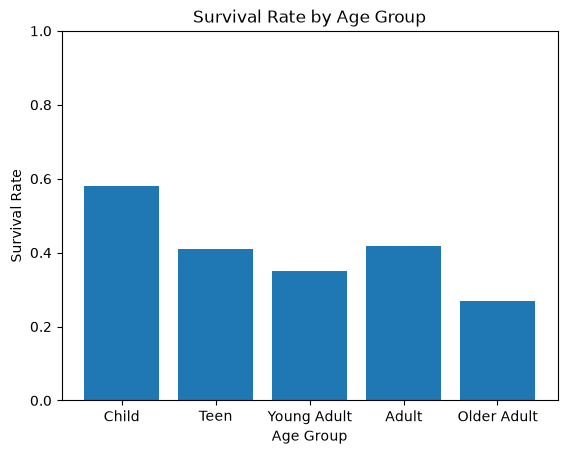

In [16]:
age_survival = age_df.groupby('Age_Group')['Survived'].mean()

plt.bar(age_survival.index, age_survival.values)
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

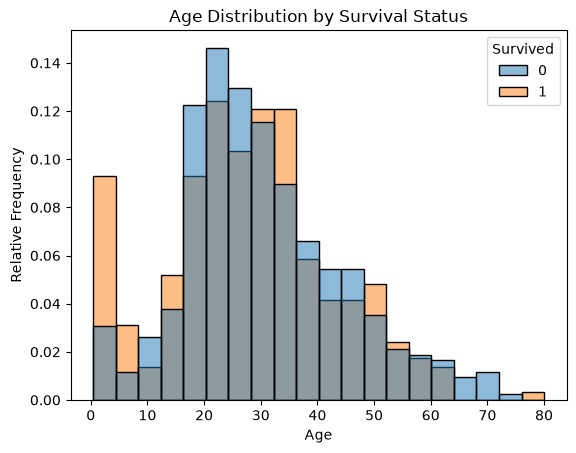

In [17]:
sns.histplot(
    data=age_df,
    x="Age",
    hue="Survived",
    bins=20,
    stat="probability",
    common_norm=False
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Age")
plt.ylabel("Relative Frequency")
plt.show()

**Observation:** Young children made up a larger proportion of survivors, while passengers in their early twenties were more represented among non-survivors. The distributions overlapped considerably for many other ages.

**Conclusion:** Female passengers, first-class passengers, and younger passengers were generally more likely to survive. Gender and passenger class showed the clearest relationship with survival, while age also had some influence.